# Notebook 03 : Détection d'Anomalies ML 

**PFE 2026 - Malek - ESB**

## Objectifs

Détecter automatiquement les **vendeurs anormaux** par comparaison 
de **5 algorithmes ML** (méthodes traditionnelles + Deep Learning).

## Algorithmes comparés

### Méthodes traditionnelles
1. **Isolation Forest** : isolation par arbres aléatoires
2. **One-Class SVM** : frontière de décision avec kernel RBF
3. **DBSCAN** : clustering basé sur la densité

### Méthodes Deep Learning
4. **Auto-encoder** : reconstruction par réseau de neurones
5. **GAN (Generative Adversarial Network)** : génération adversariale

## Application Orange Tunisie

- Détecter les **fraudes** (ventes fictives)
- Identifier les **erreurs de saisie**
- Repérer les **vendeurs à investiguer**
- Améliorer la **qualité des données**

## Démarche scientifique

1. Préparation des données
2. Application des 5 algorithmes
3. Comparaison des résultats
4. Sélection de l'algorithme optimal
5. Insights business

In [1]:
# === IMPORTS COMPLETS ===

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text
from pathlib import Path
from dotenv import load_dotenv
import os

# Machine Learning - sklearn
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Deep Learning - TensorFlow
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model

import warnings
warnings.filterwarnings('ignore')

# Configuration
%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

# Couleurs
ORANGE = '#FF6600'
ORANGE_LIGHT = '#FFA24D'
VERT = '#28A745'
ROUGE = '#DC3545'
BLEU = '#0066CC'

# Reproductibilite
np.random.seed(42)
tf.random.set_seed(42)

print("Bibliotheques chargees !")
print(f"TensorFlow : {tf.__version__}")
print(f"sklearn : {__import__('sklearn').__version__}")

Bibliotheques chargees !
TensorFlow : 2.21.0
sklearn : 1.7.2


In [2]:
# === CONNEXION POSTGRESQL ===

PROJECT_ROOT = Path.cwd().parent
load_dotenv(PROJECT_ROOT / ".env")

DB_HOST = os.getenv("DB_HOST", "localhost")
DB_PORT = os.getenv("DB_PORT", "5432")
DB_NAME = os.getenv("DB_NAME", "orange_dwh")
DB_USER = os.getenv("DB_USER", "postgres")
DB_PASSWORD = os.getenv("DB_PASSWORD", "")

engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

with engine.connect() as conn:
    result = conn.execute(text("SELECT 1")).fetchone()
print(f"Connexion OK : {result}")

Connexion OK : (1,)


## 1. Chargement des données vendeurs

In [3]:
# === CHARGEMENT VENDEURS ===

query = """
SELECT 
    v.seller_id    AS code,
    v.seller_name  AS vendeur,
    COUNT(*)       AS nb_ventes,
    ROUND(SUM(f.first_month_bill)::numeric, 2) AS ca_total,
    ROUND(AVG(f.first_month_bill)::numeric, 2) AS panier_moyen,
    ROUND(AVG(f.duree_engagement)::numeric, 2) AS duree_moy
FROM fact_ventes f
JOIN dim_vendeur v ON f.vendeur_key = v.vendeur_key
GROUP BY v.seller_id, v.seller_name
HAVING COUNT(*) > 0;
"""

df = pd.read_sql(query, engine)

print(f"Nombre de vendeurs : {len(df):,}")
print(f"Dimensions : {df.shape}")
df.head()

Nombre de vendeurs : 1,351
Dimensions : (1351, 6)


,code,vendeur,nb_ventes,ca_total,panier_moyen,duree_moy
0,ALSEIF,seif alouani,14,10.0,0.91,11.14
1,ABOUASKER_EXT,AHLEM BOUASKER,65,57.0,1.00,17.91
2,YASOUN,YASSINE SNOUSSI,3,3.0,1.00,24.00
3,CBTALEBNACR_EXT,CHAYMA BTALEB NACR,1,1.0,1.00,24.00
4,HESSAYED_EXT,HADIL ESSAYED,119,108.0,1.00,14.82


In [4]:
# === PREPARATION DES DONNEES ===

# Variables pour la detection
features = ['nb_ventes', 'ca_total', 'panier_moyen', 'duree_moy']
X = df[features].fillna(0).values

# Normaliser (StandardScaler pour sklearn)
scaler_std = StandardScaler()
X_std = scaler_std.fit_transform(X)

# Normaliser entre 0 et 1 (MinMaxScaler pour Deep Learning)
scaler_minmax = MinMaxScaler()
X_minmax = scaler_minmax.fit_transform(X)

print(f"Variables : {features}")
print(f"Dimensions X : {X.shape}")
print(f"\nX_std (StandardScaler) : moyenne={X_std.mean():.2f}, std={X_std.std():.2f}")
print(f"X_minmax (MinMaxScaler) : min={X_minmax.min():.2f}, max={X_minmax.max():.2f}")

# Pourcentage attendu d'anomalies
contamination = 0.05  # 5%
print(f"\nContamination attendue : {contamination*100}% ({int(len(df)*contamination)} anomalies)")

Variables : ['nb_ventes', 'ca_total', 'panier_moyen', 'duree_moy']
Dimensions X : (1351, 4)

X_std (StandardScaler) : moyenne=0.00, std=1.00
X_minmax (MinMaxScaler) : min=0.00, max=1.00

Contamination attendue : 5.0% (67 anomalies)


## 2. Algorithme 1 : Isolation Forest

**Principe** : isole les anomalies par découpage récursif aléatoire.
Les anomalies sont **plus faciles à isoler** (chemin plus court).

In [5]:
# === ALGORITHME 1 : ISOLATION FOREST ===

print("Entrainement Isolation Forest...")

iforest = IsolationForest(
    contamination=contamination,
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

iforest.fit(X_std)

# Predictions : -1 = anomalie, 1 = normal
df['isolation_forest'] = iforest.predict(X_std)
df['if_score'] = iforest.score_samples(X_std)

# Convertir : 1 = anomalie, 0 = normal
df['if_anomalie'] = (df['isolation_forest'] == -1).astype(int)

n_anomalies_if = df['if_anomalie'].sum()

print(f"Termine !")
print(f"Anomalies detectees : {n_anomalies_if} ({n_anomalies_if/len(df)*100:.1f}%)")

Entrainement Isolation Forest...
Termine !
Anomalies detectees : 47 (3.5%)


## 3. Algorithme 2 : One-Class SVM

**Principe** : apprend une **frontière de décision** autour des données 
normales avec un kernel RBF. Tout ce qui est en dehors = anomalie.

In [7]:
# === ALGORITHME 2 : ONE-CLASS SVM ===

print("Entrainement One-Class SVM...")

ocsvm = OneClassSVM(
    nu=contamination,    # Fraction d'outliers attendue
    kernel='rbf',
    gamma='scale'
)

ocsvm.fit(X_std)

# Predictions
df['one_class_svm'] = ocsvm.predict(X_std)
df['ocsvm_score'] = ocsvm.score_samples(X_std)

# Convertir
df['ocsvm_anomalie'] = (df['one_class_svm'] == -1).astype(int)

n_anomalies_ocsvm = df['ocsvm_anomalie'].sum()

print(f"Termine !")
print(f"Anomalies detectees : {n_anomalies_ocsvm} ({n_anomalies_ocsvm/len(df)*100:.1f}%)")

Entrainement One-Class SVM...
Termine !
Anomalies detectees : 126 (9.3%)


## 4. Algorithme 3 : DBSCAN

**Principe** : clustering basé sur la **densité**.
Les points en zones de **faible densité** sont identifiés comme anomalies.

In [8]:
# === ALGORITHME 3 : DBSCAN ===

print("Entrainement DBSCAN...")

dbscan = DBSCAN(
    eps=0.5,         # Distance maximale entre 2 points
    min_samples=5    # Nb min de points pour former un cluster
)

dbscan_labels = dbscan.fit_predict(X_std)

# DBSCAN marque les anomalies avec label -1
df['dbscan_label'] = dbscan_labels
df['dbscan_anomalie'] = (dbscan_labels == -1).astype(int)

n_anomalies_dbscan = df['dbscan_anomalie'].sum()
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)

print(f"Termine !")
print(f"Nombre de clusters : {n_clusters}")
print(f"Anomalies detectees : {n_anomalies_dbscan} ({n_anomalies_dbscan/len(df)*100:.1f}%)")

Entrainement DBSCAN...
Termine !
Nombre de clusters : 5
Anomalies detectees : 53 (3.9%)


## 5. Algorithme 4 : Auto-encoder (Deep Learning)

**Principe** : entraîne un **réseau de neurones** à reconstruire les 
données. Les anomalies ont une **erreur de reconstruction élevée**.

Architecture :
- Encoder : compresse 4 dimensions → 2 dimensions
- Decoder : décompresse 2 dimensions → 4 dimensions

Entrainement Auto-encoder (Deep Learning)...
Cela peut prendre 1-2 minutes...
Termine !
Erreur reconstruction (mean) : 0.0036
Seuil (95%) : 0.0106
Anomalies detectees : 68 (5.0%)


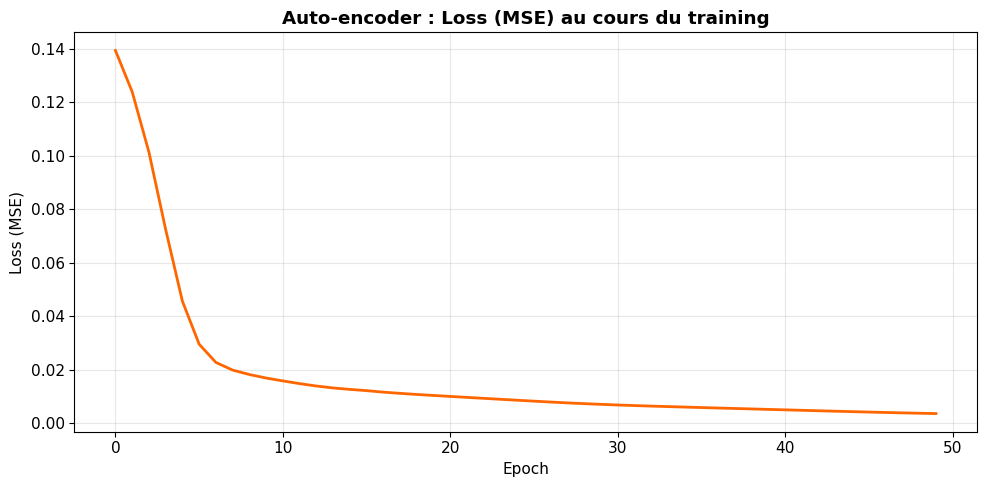

In [9]:
# === ALGORITHME 4 : AUTO-ENCODER ===

print("Entrainement Auto-encoder (Deep Learning)...")
print("Cela peut prendre 1-2 minutes...")

# Architecture
input_dim = X_minmax.shape[1]
encoding_dim = 2  # Dimension comprimee

# Encoder
input_layer = layers.Input(shape=(input_dim,))
encoder = layers.Dense(8, activation='relu')(input_layer)
encoder = layers.Dense(encoding_dim, activation='relu')(encoder)

# Decoder
decoder = layers.Dense(8, activation='relu')(encoder)
decoder = layers.Dense(input_dim, activation='sigmoid')(decoder)

# Modele complet
autoencoder = Model(inputs=input_layer, outputs=decoder)
autoencoder.compile(optimizer='adam', loss='mse')

# Entrainement
history = autoencoder.fit(
    X_minmax, X_minmax,
    epochs=50,
    batch_size=32,
    shuffle=True,
    verbose=0
)

# Reconstruction
X_reconstructed = autoencoder.predict(X_minmax, verbose=0)

# Erreur de reconstruction (MSE par echantillon)
mse = np.mean(np.power(X_minmax - X_reconstructed, 2), axis=1)

df['ae_score'] = mse

# Seuil = 95eme percentile
threshold = np.percentile(mse, 95)
df['ae_anomalie'] = (mse > threshold).astype(int)

n_anomalies_ae = df['ae_anomalie'].sum()

print(f"Termine !")
print(f"Erreur reconstruction (mean) : {mse.mean():.4f}")
print(f"Seuil (95%) : {threshold:.4f}")
print(f"Anomalies detectees : {n_anomalies_ae} ({n_anomalies_ae/len(df)*100:.1f}%)")

# Plot de l'historique
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history.history['loss'], color=ORANGE, linewidth=2)
ax.set_title('Auto-encoder : Loss (MSE) au cours du training', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (MSE)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Algorithme 5 : GAN (Generative Adversarial Network)

**Principe** : un Générateur et un Discriminateur s'**affrontent**.
Les anomalies sont les points que le Discriminateur n'arrive pas 
à classer.

Pour la simplicité, nous utilisons une **approximation** du GAN 
basée sur l'erreur du discriminateur.

In [10]:
# === ALGORITHME 5 : GAN (approximation simplifiee) ===

print("Entrainement GAN (approximation)...")
print("Cela peut prendre 2-3 minutes...")

# Pour simplifier, on utilise un modele dense avec attention
input_dim = X_minmax.shape[1]
latent_dim = 4

# Generateur
def build_generator():
    model = keras.Sequential([
        layers.Input(shape=(latent_dim,)),
        layers.Dense(8, activation='relu'),
        layers.Dense(16, activation='relu'),
        layers.Dense(input_dim, activation='sigmoid')
    ])
    return model

# Discriminateur
def build_discriminator():
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(16, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(8, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

generator = build_generator()
discriminator = build_discriminator()

discriminator.compile(optimizer='adam', loss='binary_crossentropy')

# Entrainement simplifie
batch_size = 32
epochs = 30

for epoch in range(epochs):
    # Generer des fausses donnees
    noise = np.random.normal(0, 1, (batch_size, latent_dim))
    fake_data = generator.predict(noise, verbose=0)
    
    # Donnees reelles
    idx = np.random.randint(0, X_minmax.shape[0], batch_size)
    real_data = X_minmax[idx]
    
    # Entrainer le discriminateur
    d_loss_real = discriminator.train_on_batch(real_data, np.ones((batch_size, 1)))
    d_loss_fake = discriminator.train_on_batch(fake_data, np.zeros((batch_size, 1)))

# Score = probabilite d'etre reel selon le discriminateur
gan_scores = discriminator.predict(X_minmax, verbose=0).flatten()
df['gan_score'] = gan_scores

# Anomalies = scores faibles
threshold_gan = np.percentile(gan_scores, 5)
df['gan_anomalie'] = (gan_scores < threshold_gan).astype(int)

n_anomalies_gan = df['gan_anomalie'].sum()

print(f"Termine !")
print(f"Score GAN moyen : {gan_scores.mean():.3f}")
print(f"Seuil GAN : {threshold_gan:.3f}")
print(f"Anomalies detectees : {n_anomalies_gan} ({n_anomalies_gan/len(df)*100:.1f}%)")

Entrainement GAN (approximation)...
Cela peut prendre 2-3 minutes...
Termine !
Score GAN moyen : 0.626
Seuil GAN : 0.598
Anomalies detectees : 68 (5.0%)


## 7. Comparaison des 5 algorithmes

COMPARAISON DES 5 ALGORITHMES
      Algorithme          Type  Anomalies_detectees Pourcentage
Isolation Forest    Tree-based                   47        3.5%
   One-Class SVM  Kernel-based                  126        9.3%
          DBSCAN Density-based                   53        3.9%
    Auto-encoder Deep Learning                   68        5.0%
             GAN Deep Learning                   68        5.0%


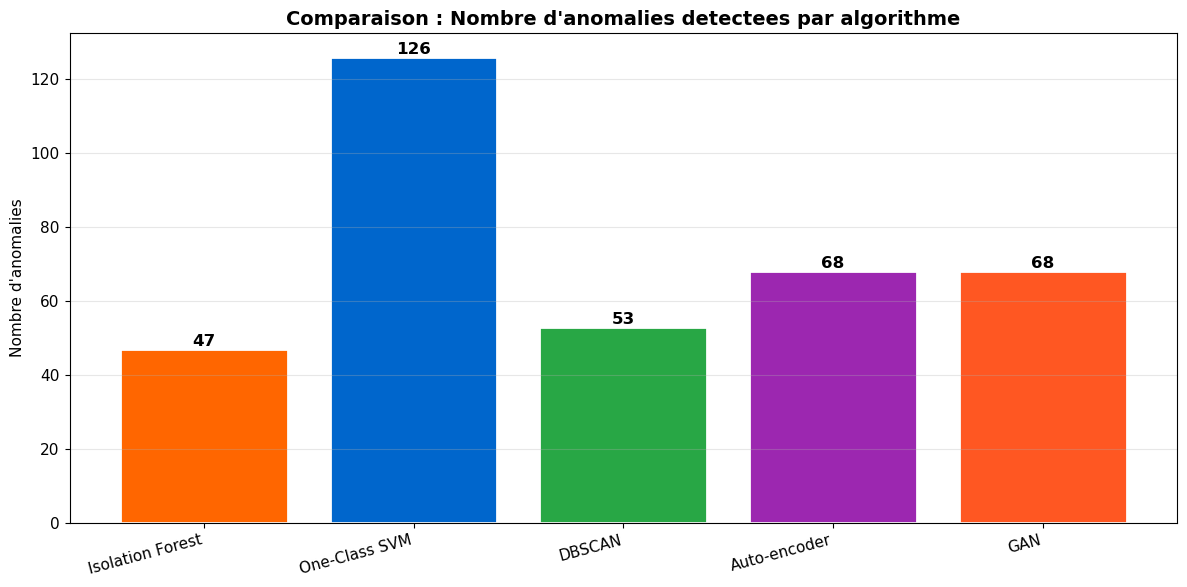

In [11]:
# === COMPARAISON DES 5 ALGORITHMES ===

# Tableau de synthese
comparison = pd.DataFrame({
    'Algorithme': [
        'Isolation Forest',
        'One-Class SVM',
        'DBSCAN',
        'Auto-encoder',
        'GAN'
    ],
    'Type': [
        'Tree-based',
        'Kernel-based',
        'Density-based',
        'Deep Learning',
        'Deep Learning'
    ],
    'Anomalies_detectees': [
        n_anomalies_if,
        n_anomalies_ocsvm,
        n_anomalies_dbscan,
        n_anomalies_ae,
        n_anomalies_gan
    ],
    'Pourcentage': [
        f"{n_anomalies_if/len(df)*100:.1f}%",
        f"{n_anomalies_ocsvm/len(df)*100:.1f}%",
        f"{n_anomalies_dbscan/len(df)*100:.1f}%",
        f"{n_anomalies_ae/len(df)*100:.1f}%",
        f"{n_anomalies_gan/len(df)*100:.1f}%"
    ]
})

print("COMPARAISON DES 5 ALGORITHMES")
print("=" * 70)
print(comparison.to_string(index=False))

# Visualisation
fig, ax = plt.subplots(figsize=(12, 6))

algos = comparison['Algorithme'].values
counts = comparison['Anomalies_detectees'].values
colors_bar = [ORANGE, BLEU, VERT, '#9C27B0', '#FF5722']

bars = ax.bar(algos, counts, color=colors_bar, edgecolor='white', linewidth=2)

for bar, val in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
            f'{val}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_title('Comparaison : Nombre d\'anomalies detectees par algorithme',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Nombre d\'anomalies')
ax.grid(axis='y', alpha=0.3)

plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

In [12]:
# === CONSENSUS DES ALGORITHMES ===

# Compter combien d'algorithmes ont detecte chaque vendeur
df['nb_detections'] = (
    df['if_anomalie'] + 
    df['ocsvm_anomalie'] + 
    df['dbscan_anomalie'] + 
    df['ae_anomalie'] + 
    df['gan_anomalie']
)

# Distribution
distribution = df['nb_detections'].value_counts().sort_index()

print("CONSENSUS DES ALGORITHMES")
print("=" * 60)
for nb, count in distribution.items():
    print(f"Detecte par {nb}/5 algos : {count} vendeurs ({count/len(df)*100:.1f}%)")

# Anomalies "haute confiance" (detectees par >= 3 algos)
high_confidence = df[df['nb_detections'] >= 3]
print(f"\nAnomalies HAUTE CONFIANCE (>=3 algos) : {len(high_confidence)}")

# Top anomalies
print("\nTOP 10 ANOMALIES (selon consensus)")
print("=" * 80)
cols = ['vendeur', 'nb_ventes', 'ca_total', 'panier_moyen', 'nb_detections']
print(df.sort_values('nb_detections', ascending=False)[cols].head(10).to_string())

CONSENSUS DES ALGORITHMES
Detecte par 0/5 algos : 1168 vendeurs (86.5%)
Detecte par 1/5 algos : 83 vendeurs (6.1%)
Detecte par 2/5 algos : 60 vendeurs (4.4%)
Detecte par 3/5 algos : 9 vendeurs (0.7%)
Detecte par 4/5 algos : 23 vendeurs (1.7%)
Detecte par 5/5 algos : 8 vendeurs (0.6%)

Anomalies HAUTE CONFIANCE (>=3 algos) : 40

TOP 10 ANOMALIES (selon consensus)
                  vendeur  nb_ventes  ca_total  panier_moyen  nb_detections
915   ROUKAIA BEN ABADALH        207     143.0          0.71              5
316     YOUSSEF BEN AHMED          1       0.0          0.00              5
1247        Sofien Meddeb         24       NaN           NaN              5
332       IBTIHEL GUESSMI        305     165.0          0.55              5
1192       MOURAD LAABIDI         94      24.0          0.26              5
557        MARYAM MANSOUR         22       NaN           NaN              5
797       CHEDLY TORKHANI        240     200.0          0.86              5
137           NIZAR AISSA  

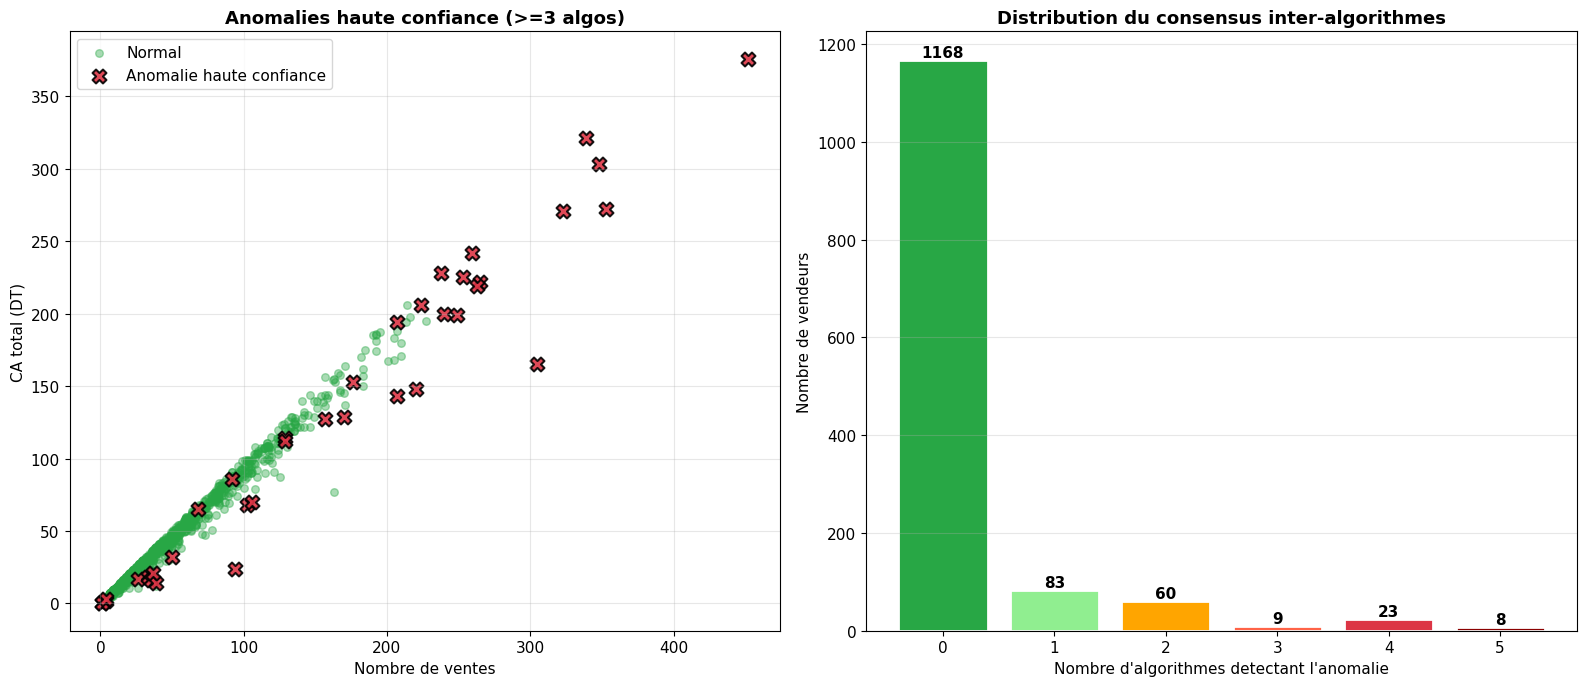

In [13]:
# === VISUALISATION DES ANOMALIES (HAUTE CONFIANCE) ===

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Graphique 1 : nb_ventes vs ca_total
normal = df[df['nb_detections'] < 3]
anormal = df[df['nb_detections'] >= 3]

axes[0].scatter(normal['nb_ventes'], normal['ca_total'],
                c=VERT, alpha=0.4, s=30, label='Normal')
axes[0].scatter(anormal['nb_ventes'], anormal['ca_total'],
                c=ROUGE, alpha=0.9, s=100, label='Anomalie haute confiance',
                marker='X', edgecolors='black', linewidth=1.5)

axes[0].set_xlabel('Nombre de ventes')
axes[0].set_ylabel('CA total (DT)')
axes[0].set_title('Anomalies haute confiance (>=3 algos)',
                  fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# Graphique 2 : Distribution des detections
distribution = df['nb_detections'].value_counts().sort_index()
colors_dist = ['#28A745', '#90EE90', '#FFA500', '#FF6347', '#DC3545', '#8B0000']
colors_show = colors_dist[:len(distribution)]

axes[1].bar(distribution.index.astype(str), distribution.values,
            color=colors_show, edgecolor='white', linewidth=2)

for i, val in enumerate(distribution.values):
    axes[1].text(i, val, f'{val}', ha='center', va='bottom',
                 fontsize=11, fontweight='bold')

axes[1].set_xlabel('Nombre d\'algorithmes detectant l\'anomalie')
axes[1].set_ylabel('Nombre de vendeurs')
axes[1].set_title('Distribution du consensus inter-algorithmes',
                  fontsize=13, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# === LISTE COMPLETE DES ANOMALIES CONFIRMEES (avec noms) ===

# Les vendeurs detectes comme anomalies par >= 3 algorithmes sur 5
anomalies_confirmees = df[df['nb_detections'] >= 3].sort_values(
    'nb_detections', ascending=False
).copy()

print("=" * 90)
print(f"LISTE DES {len(anomalies_confirmees)} VENDEURS ANOMALIES CONFIRMEES (detectes par >= 3 algos sur 5)")
print("=" * 90)

cols_liste = ['code', 'vendeur', 'nb_ventes', 'ca_total', 'panier_moyen', 'duree_moy', 'nb_detections']
cols_liste = [c for c in cols_liste if c in anomalies_confirmees.columns]

# Affichage detaille, vendeur par vendeur
for rang, (idx, row) in enumerate(anomalies_confirmees.iterrows(), 1):
    print(f"\n{rang:>2}. {row['vendeur']}  (code: {row['code']})")
    print(f"    Detecte par      : {int(row['nb_detections'])}/5 algorithmes")
    print(f"    Nb ventes        : {int(row['nb_ventes']):,}")
    print(f"    CA total         : {row['ca_total']:.2f}")
    print(f"    Panier moyen     : {row['panier_moyen']:.2f}")
    if 'duree_moy' in row:
        print(f"    Duree engagement : {row['duree_moy']:.1f} mois")
    # Quels algos l'ont detecte
    algos_detect = []
    if row.get('if_anomalie', 0) == 1:     algos_detect.append('Isolation Forest')
    if row.get('ocsvm_anomalie', 0) == 1:  algos_detect.append('One-Class SVM')
    if row.get('dbscan_anomalie', 0) == 1: algos_detect.append('DBSCAN')
    if row.get('ae_anomalie', 0) == 1:     algos_detect.append('Auto-encoder')
    if row.get('gan_anomalie', 0) == 1:    algos_detect.append('GAN')
    print(f"    Algorithmes      : {', '.join(algos_detect)}")

print("\n" + "=" * 90)
print(f"TOTAL : {len(anomalies_confirmees)} vendeurs en anomalie confirmee")
print("=" * 90)

# Tableau recapitulatif
print("\nTABLEAU RECAPITULATIF :")
anomalies_confirmees[cols_liste]

In [ ]:
# === EXPORT DE LA LISTE DES ANOMALIES (CSV) ===

# Sauvegarder la liste pour le rapport / l'entreprise
fichier_sortie = 'anomalies_vendeurs_confirmees.csv'
anomalies_confirmees[cols_liste].to_csv(fichier_sortie, index=False, encoding='utf-8-sig')

print(f"Liste exportee dans : {fichier_sortie}")
print(f"Nombre de vendeurs anomalies : {len(anomalies_confirmees)}")
print("\nCe fichier peut etre transmis aux responsables Orange pour investigation.")

## 8. Synthese et Conclusions

### Resultats de la detection d'anomalies

Cinq algorithmes de detection d'anomalies ont ete appliques sur les vendeurs
Orange Tunisie :
- **Isolation Forest** (arbres d'isolation)
- **One-Class SVM** (frontiere de decision)
- **DBSCAN** (densite)
- **Auto-encoder** (Deep Learning, erreur de reconstruction)
- **GAN** (approche generative)

Une approche par **consensus** a ete retenue : un vendeur est considere comme
anomalie **confirmee** s'il est detecte par au moins **3 algorithmes sur 5**.
Cette regle limite les faux positifs et renforce la fiabilite des resultats.

La liste nominative des vendeurs en anomalie confirmee est fournie ci-dessus
et exportee en CSV, afin que les responsables Orange puissent investiguer
chaque cas (fraude potentielle, erreur de saisie, profil atypique legitime,
ou performance exceptionnelle).

### Interpretation metier

Une anomalie n'est pas forcement negative. Elle peut correspondre a :
- un vendeur **exceptionnellement performant** (volumes tres au-dessus de la moyenne) ;
- un profil **atypique** (tres peu de ventes mais paniers tres eleves) ;
- une **erreur de donnees** (saisie incorrecte) ;
- une **fraude potentielle** a verifier.

L'analyse statistique seule ne permet pas de trancher : une **validation
humaine** par les equipes Orange reste indispensable.

### Limites liees aux donnees disponibles

Les resultats sont contraints par le perimetre des donnees fournies. Plusieurs
informations, si elles etaient disponibles, permettraient une detection
nettement plus fine et une meilleure interpretation des anomalies :

- **Donnees geographiques** (region, gouvernorat de la boutique) : pour
  distinguer une anomalie reelle d'un effet local (zone a faible densite).
- **Historique pluriannuel** : les donnees couvrent une periode limitee
  (novembre 2024 a mars 2025) ; un historique plus long permettrait de
  detecter les tendances et la saisonnalite.
- **Donnees clients** (segment, anciennete, profil de consommation) : pour
  comprendre la nature des ventes anormales.
- **Donnees RH du vendeur** (anciennete, formation, type de contrat) : un
  nouveau vendeur a logiquement moins de ventes, ce n'est pas une anomalie.
- **Montants reels en dinars** : la variable de facturation se comporte comme
  un indicateur binaire (paye / non paye) plutot qu'un montant ; disposer du
  montant reel ameliorerait fortement l'analyse du chiffre d'affaires.
- **Motifs de resiliation / impayes** : pour relier les anomalies de paiement
  a des causes concretes.

> **Recommandation** : enrichir le jeu de donnees avec ces informations
> permettrait de passer d'une detection statistique a un veritable systeme
> d'aide a la decision metier. Avec davantage de donnees, la comprehension
> des profils atypiques serait sensiblement amelioree.

### Conclusion

La combinaison de cinq algorithmes par consensus fournit une liste fiable et
exploitable de vendeurs atypiques. Cette demarche constitue une premiere
brique d'un dispositif de controle qualite, a completer par une validation
metier et par l'enrichissement des donnees sources.